# Assignment 6: Naïve Bayes Classification on Iris Dataset

## Objective
Implement Naïve Bayes classification algorithm using Python on iris.csv dataset and compute confusion matrix with evaluation metrics.

## Steps
1. Import libraries
2. Load and explore the dataset
3. Data preprocessing
4. Split data into training and testing sets
5. Train Naïve Bayes model
6. Make predictions
7. Evaluate model performance
8. Calculate evaluation parameters

## Step 1: Import Libraries and Create Alias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

## Step 2-3: Load and Initialize the Dataset

In [3]:
# Load dataset and display rows
df = pd.read_csv('Iris.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (150, 6)

First few rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Check dataset info and summary statistics
print("Dataset Info:")
df.info()
print("\nDataset Description:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

Dataset Description:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Step 4: Data Preprocessing

In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0


In [6]:
# Check unique target classes
print("Unique classes in target variable:")
print(df['Species'].unique())
print("\nClass distribution:")
print(df['Species'].value_counts())

Unique classes in target variable:
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [8]:
# Divide dataset into Independent (X) and Dependent (Y) variables
# Keeping 'Species' as the target variable
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # Last column (Species)

print("Features (X) shape:", X.shape)
print("Target (Y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (150, 5)
Target (Y) shape: (150,)

Feature columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [9]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 120
Testing set size: 30

Training set class distribution:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Testing set class distribution:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## Step 5: Train Naïve Bayes Classifier

In [10]:
# Create and train the Gaussian Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of classes: {len(nb_model.classes_)}")
print(f"Classes: {nb_model.classes_}")

Model trained successfully!
Number of classes: 3
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Step 6: Predict on Training and Testing Data

In [11]:
# Make predictions on training and testing sets
y_pred_train = nb_model.predict(X_train)
y_pred_test = nb_model.predict(X_test)

print("Predictions on training set (first 10):")
print(y_pred_train[:10])
print("\nPredictions on testing set (first 10):")
print(y_pred_test[:10])

Predictions on training set (first 10):
['Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica']

Predictions on testing set (first 10):
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']


## Step 7-8: Model Evaluation and Performance Metrics

In [12]:
# Calculate confusion matrix for testing set
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix for Testing Set:")
print(cm)
print("\nLabels (Classes):", nb_model.classes_)

Confusion Matrix for Testing Set:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Labels (Classes): ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [14]:
# Function to calculate evaluation metrics from confusion matrix (for multi-class)
def calculate_metrics(y_true, y_pred):
    """
    Calculate various evaluation metrics for multi-class classification
    """
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # Error Rate
    error_rate = 1 - accuracy
    
    # Precision, Recall, F1-Score (macro average for multi-class)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'Accuracy': accuracy,
        'Error Rate': error_rate,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Calculate metrics for both sets
train_metrics = calculate_metrics(y_train, y_pred_train)
test_metrics = calculate_metrics(y_test, y_pred_test)

print("\n" + "="*50)
print("TRAINING SET METRICS")
print("="*50)
for metric, value in train_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n" + "="*50)
print("TESTING SET METRICS")
print("="*50)
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")


TRAINING SET METRICS
Accuracy: 0.9917
Error Rate: 0.0083
Precision: 0.9919
Recall: 0.9917
F1-Score: 0.9917

TESTING SET METRICS
Accuracy: 1.0000
Error Rate: 0.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [15]:
# Detailed per-class metrics
from sklearn.metrics import classification_report

print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT (Testing Set)")
print("="*50)
print(classification_report(y_test, y_pred_test))


DETAILED CLASSIFICATION REPORT (Testing Set)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



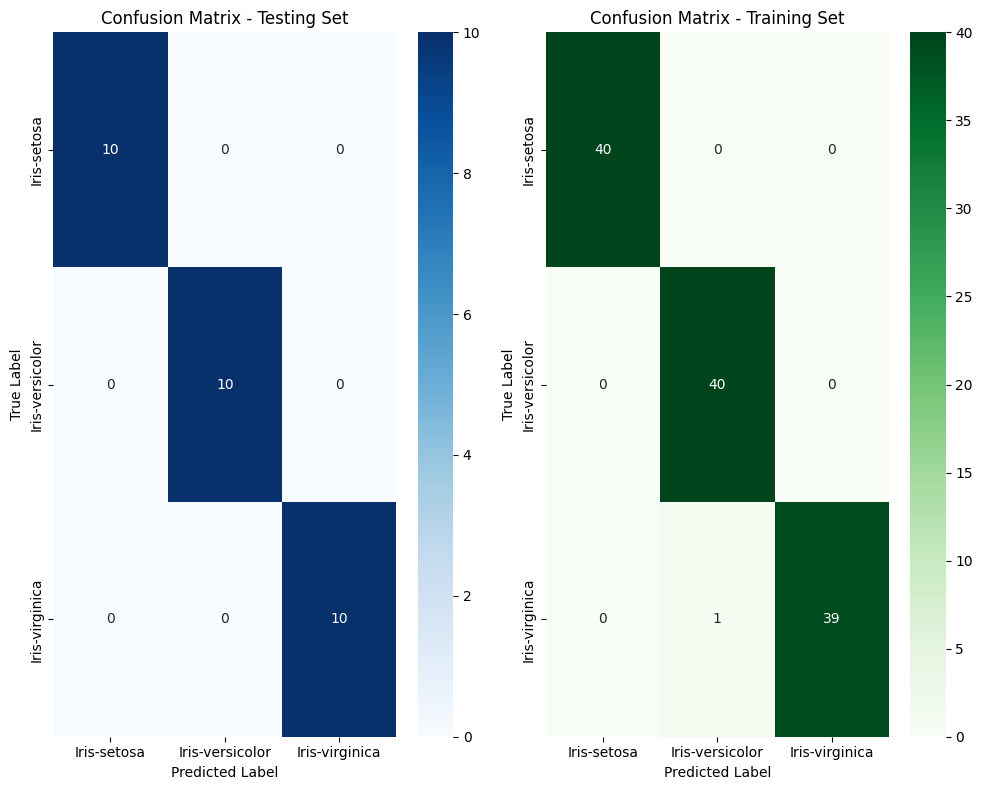

In [16]:
# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))

# Testing set confusion matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_,
            cbar=True)
plt.title('Confusion Matrix - Testing Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_pred_train)
plt.subplot(1, 2, 2)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_,
            cbar=True)
plt.title('Confusion Matrix - Training Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()


Metrics Comparison:
            Training  Testing
Accuracy      0.9917      1.0
Error Rate    0.0083      0.0
Precision     0.9919      1.0
Recall        0.9917      1.0
F1-Score      0.9917      1.0


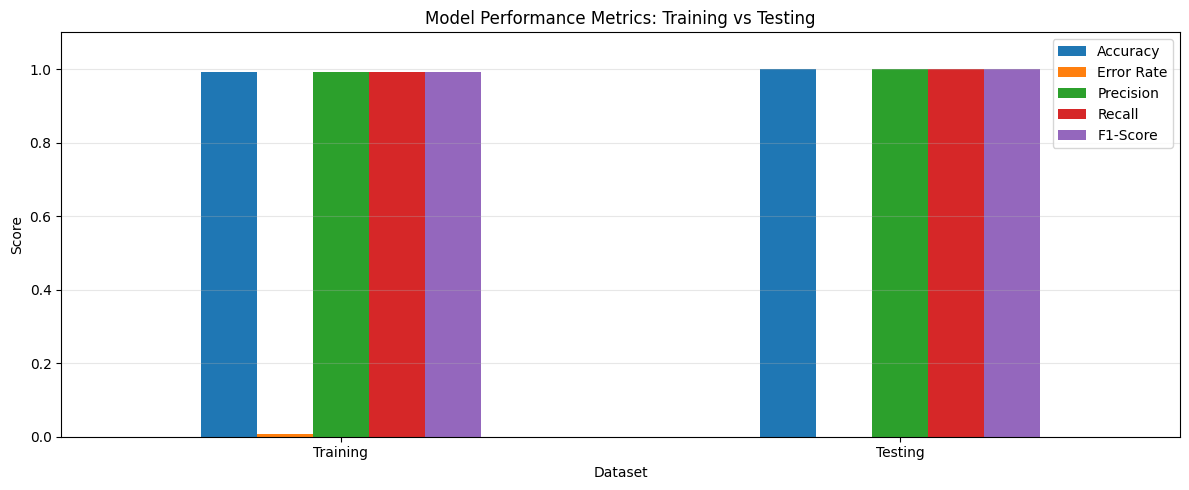

In [17]:
# Compare Training vs Testing Metrics
metrics_comparison = pd.DataFrame({
    'Training': train_metrics,
    'Testing': test_metrics
})

print("\nMetrics Comparison:")
print(metrics_comparison.round(4))

# Visualize metrics comparison
metrics_comparison.T.plot(kind='bar', figsize=(12, 5))
plt.title('Model Performance Metrics: Training vs Testing')
plt.ylabel('Score')
plt.xlabel('Dataset')
plt.legend(loc='best')
plt.xticks(rotation=0)
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of Evaluation Parameters

### Testing Set Results:
- **Accuracy**: Proportion of correct predictions out of total predictions
- **Error Rate**: Proportion of incorrect predictions (1 - Accuracy)
- **Precision**: Of all positive predictions, how many were correct
- **Recall**: Of all actual positives, how many did we identify
- **F1-Score**: Harmonic mean of Precision and Recall

### Confusion Matrix Interpretation:
- **True Positives (TP)**: Correctly predicted positive class
- **True Negatives (TN)**: Correctly predicted negative class
- **False Positives (FP)**: Incorrectly predicted as positive
- **False Negatives (FN)**: Incorrectly predicted as negative